# E-Commerce Transaction & Revenue Performance Analysis

### Dataset Overview
The dataset contains transactional e-commerce order records spanning from January 1, 2024 to August 16, 2026.  
* Volume & Dimensions: 1,100,000 rows and 12 columns (after feature engineering).  
* Missing & Duplicate Values: 0 missing entries (100% complete) and 0 duplicate records.  
### Key Fields:
**Identifiers & Attributes**: Order_ID, Product (20 unique products), Category (9 unique categories), and City (20 tier-1 & tier-2 Indian metropolitan cities).  
**Numerical & Financials**: Quantity (range: 1–5 units), Price (INR 150 to INR 85,000), and derived Revenue (Quantity × Price).  
**Temporal Attributes**: Date, Year, Month, DayofWeek, and Day. 

### Technical Stack
* **Language**: Python
* **Data Manipulation**: pandas, NumPy
* **Visualization**: Matplotlib, Seaborn
* **Modeling (Pipeline Ready)**: scikit-learn (`StandardScaler`, `KMeans`, `LabelEncoder`)

In [127]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score


import os
import warnings

warnings.filterwarnings('ignore')

### LOAD & PREPARE DATA

In [89]:
file_path = 'ecommerce_sales_1.1.csv'
df = pd.read_csv(file_path)

In [90]:
# Convert datetimes and generate financial columns

df['Date'] = pd.to_datetime(df['Date'])
df['Revenue'] = df['Quantity'] * df['Price']
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayofWeek'] = df['Date'].dt.dayofweek
df['Day'] = df['Date'].dt.day

print(f'Total Rows: {len(df):,}')
print(f'Total Columns: {len(df.columns):,}')
print(f'Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}')

Total Rows: 1,100,000
Total Columns: 12
Date Range: 2024-01-01 to 2026-08-16


Feature Engineering: Financial and temporal metrics are extracted:  
* Financial: Revenue = Quantity * Price  
* Calendar: Year, Month, DayofWeek, and Day  

#### Data Integrity & Profiling

In [91]:
df_copy = df.copy()

In [92]:
df_copy.head().style.background_gradient(cmap = 'coolwarm')

,Order_ID,Product,Category,Quantity,Price,City,Date,Revenue,Year,Month,DayofWeek,Day
0,ORD0000001,Smartphone,Electronics,3,13376,Jaipur,2026-05-31 00:00:00,40128,2026,5,6,31
1,ORD0000002,Bedsheet,Home & Living,5,1979,Bengaluru,2024-11-02 00:00:00,9895,2024,11,5,2
2,ORD0000003,Coffee Maker,Home Appliances,5,3061,Ahmedabad,2026-04-25 00:00:00,15305,2026,4,5,25
3,ORD0000004,Shoes,Footwear,3,1551,Nagpur,2026-08-08 00:00:00,4653,2026,8,5,8
4,ORD0000005,Shoes,Footwear,3,1537,Jaipur,2024-12-27 00:00:00,4611,2024,12,4,27


In [93]:
df_copy.tail().style.background_gradient(cmap = 'coolwarm')

,Order_ID,Product,Category,Quantity,Price,City,Date,Revenue,Year,Month,DayofWeek,Day
1099995,ORD1099996,Mixer Grinder,Home Appliances,1,6255,Ahmedabad,2024-02-18 00:00:00,6255,2024,2,6,18
1099996,ORD1099997,T-Shirt,Clothing,5,1194,Kolkata,2026-01-15 00:00:00,5970,2026,1,3,15
1099997,ORD1099998,Wallet,Accessories,2,692,Hyderabad,2025-10-05 00:00:00,1384,2025,10,6,5
1099998,ORD1099999,Smartphone,Electronics,1,30440,Chennai,2026-02-12 00:00:00,30440,2026,2,3,12
1099999,ORD1100000,Shoes,Footwear,5,5501,Jaipur,2024-07-14 00:00:00,27505,2024,7,6,14


In [94]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 12 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   Order_ID   1100000 non-null  str           
 1   Product    1100000 non-null  str           
 2   Category   1100000 non-null  str           
 3   Quantity   1100000 non-null  int64         
 4   Price      1100000 non-null  int64         
 5   City       1100000 non-null  str           
 6   Date       1100000 non-null  datetime64[us]
 7   Revenue    1100000 non-null  int64         
 8   Year       1100000 non-null  int32         
 9   Month      1100000 non-null  int32         
 10  DayofWeek  1100000 non-null  int32         
 11  Day        1100000 non-null  int32         
dtypes: datetime64[us](1), int32(4), int64(3), str(4)
memory usage: 83.9 MB


In [95]:
df_copy.dtypes

Order_ID                str
Product                 str
Category                str
Quantity              int64
Price                 int64
City                    str
Date         datetime64[us]
Revenue               int64
Year                  int32
Month                 int32
DayofWeek             int32
Day                   int32
dtype: object

In [96]:
df_copy.describe().style.background_gradient(cmap = 'coolwarm')

,Quantity,Price,Date,Revenue,Year,Month,DayofWeek,Day
count,1100000.000000,1100000.000000,1100000,1100000.000000,1100000.000000,1100000.000000,1100000.000000,1100000.000000
mean,2.999848,10068.848878,2025-04-24 01:27:06.964364,30259.019546,2024.856301,5.990670,3.000450,15.617600
min,1.000000,150.000000,2024-01-01 00:00:00,150.000000,2024.000000,1.000000,0.000000,1.000000
25%,2.000000,1590.000000,2024-08-27 00:00:00,3885.000000,2024.000000,3.000000,1.000000,8.000000
50%,3.000000,3220.000000,2025-04-24 00:00:00,8953.000000,2025.000000,6.000000,3.000000,16.000000
75%,4.000000,8496.000000,2025-12-20 00:00:00,24324.000000,2025.000000,9.000000,5.000000,23.000000
max,5.000000,85000.000000,2026-08-16 00:00:00,424975.000000,2026.000000,12.000000,6.000000,31.000000
std,1.413653,17113.204646,nan,58654.131963,0.774132,3.331550,2.000959,8.786712


In [97]:
df_copy.describe(include = 'object').style.background_gradient(cmap = 'coolwarm')

,Order_ID,Product,Category,City
count,1100000,1100000,1100000,1100000
unique,1100000,20,9,20
top,ORD0000001,Backpack,Electronics,Delhi
freq,1,55323,275198,55357


- there are 20 varieties of product in 9 difefrent categories.
- backpack is the most frequest order in the list.
- most order has been came from the electronic category

In [98]:
df.columns

Index(['Order_ID', 'Product', 'Category', 'Quantity', 'Price', 'City', 'Date',
       'Revenue', 'Year', 'Month', 'DayofWeek', 'Day'],
      dtype='str')

In [99]:
duplicated = df_copy.duplicated().sum()
print(f'Duplicated Rows: {duplicated}')

Duplicated Rows: 0


In [100]:
df_copy.drop_duplicates(inplace = True)

In [101]:
df_copy.shape

(1100000, 12)

In [102]:
df_copy.nunique()

Order_ID     1100000
Product           20
Category           9
Quantity           5
Price          76793
City              20
Date             959
Revenue       136744
Year               3
Month             12
DayofWeek          7
Day               31
dtype: int64

- Structural verification via info(), describe(), and nunique().  
- Duplicate detection confirms full unique integrity across all 1.1M rows.  

* **Findings**:
  * The dataset exhibits complete data hygiene with no null or duplicate records.
  * Basket sizes are strictly bounded between 1 and 5 units (mean: 3.00 units, standard deviation: 1.41), confirming retail end-consumer behavior.
  * The median product price is ₹3,220.00, while the average is ₹10,068.85 with a standard deviation of ₹17,113.20, pointing to a right-skewed pricing distribution driven by high-ticket items.

### Dimensional & Catalog Aggregations

In [103]:
categorical_columns = df_copy.select_dtypes(include = 'object').columns

for i in categorical_columns:
    print(f'n\{i})'),
    print(df_copy[i].value_counts())

n\Order_ID)
Order_ID
ORD0000001    1
ORD0000002    1
ORD0000003    1
ORD0000004    1
ORD0000005    1
             ..
ORD1099996    1
ORD1099997    1
ORD1099998    1
ORD1099999    1
ORD1100000    1
Name: count, Length: 1100000, dtype: int64
n\Product)
Product
Backpack         55323
Wallet           55307
Smart Watch      55264
Mixer Grinder    55204
Headphones       55162
Shoes            55096
Curtains         55093
Books            55053
Smartphone       55042
Jeans            55040
Tablet           54975
Jacket           54971
Sandals          54937
Cookware Set     54899
Bedsheet         54880
Coffee Maker     54829
T-Shirt          54776
Laptop           54755
Study Table      54736
Office Chair     54658
Name: count, dtype: int64
n\Category)
Category
Electronics        275198
Clothing           164787
Accessories        110630
Home Appliances    110033
Footwear           110033
Home & Living      109973
Furniture          109394
Books               55053
Kitchen             54899


In [104]:
categorical_columns = df_copy.select_dtypes(include = 'object').columns

for i in categorical_columns:
    print(f'n\{i})'),
    
    print(df_copy[i].unique())

n\Order_ID)
<StringArray>
['ORD0000001', 'ORD0000002', 'ORD0000003', 'ORD0000004', 'ORD0000005',
 'ORD0000006', 'ORD0000007', 'ORD0000008', 'ORD0000009', 'ORD0000010',
 ...
 'ORD1099991', 'ORD1099992', 'ORD1099993', 'ORD1099994', 'ORD1099995',
 'ORD1099996', 'ORD1099997', 'ORD1099998', 'ORD1099999', 'ORD1100000']
Length: 1100000, dtype: str
n\Product)
<StringArray>
[   'Smartphone',      'Bedsheet',  'Coffee Maker',         'Shoes',
  'Office Chair',        'Tablet',      'Backpack',         'Books',
  'Cookware Set',    'Headphones',      'Curtains',       'Sandals',
        'Jacket',   'Smart Watch',   'Study Table', 'Mixer Grinder',
        'Wallet',       'T-Shirt',        'Laptop',         'Jeans']
Length: 20, dtype: str
n\Category)
<StringArray>
[    'Electronics',   'Home & Living', 'Home Appliances',        'Footwear',
       'Furniture',     'Accessories',           'Books',         'Kitchen',
        'Clothing']
Length: 9, dtype: str
n\City)
<StringArray>
[   'Jaipur', 'Benga

In [105]:
category_products = df_copy.groupby('Category')['Product'].unique()

print(category_products)

Category
Accessories                                       [Backpack, Wallet]
Books                                                        [Books]
Clothing                                    [Jacket, T-Shirt, Jeans]
Electronics        [Smartphone, Tablet, Headphones, Smart Watch, ...
Footwear                                            [Shoes, Sandals]
Furniture                                [Office Chair, Study Table]
Home & Living                                   [Bedsheet, Curtains]
Home Appliances                        [Coffee Maker, Mixer Grinder]
Kitchen                                               [Cookware Set]
Name: Product, dtype: object


* **Procedure**: Conducted group-level segmentations to identify volume drivers versus margin drivers across departments and regional nodes.
* **Findings**:
  * **Volume Distribution**: Product demand is evenly distributed, ranging from 54,658 orders for Office Chairs to 55,323 orders for Backpacks.
  * **Category Concentration**: Electronics holds the highest departmental volume (275,198 orders), followed by Clothing (164,787 orders).
  * **Geographic Regularity**: Transaction counts across all 20 cities remain within a tight margin of 54,616 (Patna) to 55,357 (Delhi), indicating consistent regional platform penetration.

### Exploratory Aggregations (KPIs)

In [131]:
# Category Financial Performance

city_kpis = df_copy.groupby('City').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Quantity = ('Quantity', 'sum'),
    Total_Orders = ('Order_ID', 'count'),
    Avg_Order_Value = ('Revenue', 'mean')
).reset_index().sort_values(by = 'Total_Revenue', ascending = False)

print("\n--- Top Cities by Revenue ---")
print(city_kpis.to_string(index=False))


--- Top Cities by Revenue ---
     City  Total_Revenue  Total_Quantity  Total_Orders  Avg_Order_Value
    Kochi     1701076431          165331         55232     30798.747664
   Bhopal     1681892244          164824         54993     30583.751459
  Lucknow     1676816191          164810         54850     30570.942407
   Mumbai     1676530228          164898         54846     30567.958064
     Pune     1676216736          164426         54929     30516.061388
    Surat     1676123309          165468         55209     30359.602764
Hyderabad     1672672104          165754         55233     30283.926348
   Rajkot     1672011802          164860         55147     30319.179683
 Gurugram     1671531478          165860         55198     30282.464546
  Chennai     1666992237          164543         54695     30477.963927
    Delhi     1664824871          166315         55357     30074.333345
    Patna     1660202205          164209         54616     30397.726033
Ahmedabad     1657875383         

Electronics dominates revenue generation, producing **₹25.17 billion** (~75.6% of overall platform gross revenue) with an Average Unit Price of ₹30,411.30.

| Category | Total Orders | Total Quantity | Avg. Unit Price (INR) | Total Revenue (INR) |
| :--- | :--- | :--- | :--- | :--- |
| **Electronics** | 275,198 | 827,051 | ₹30,411.30 | ₹25,168,365,850 |
| **Furniture** | 109,394 | 328,441 | ₹8,758.90 | ₹2,877,418,786 |
| **Home Appliances** | 110,033 | 329,877 | ₹4,873.54 | ₹1,607,495,235 |
| **Clothing** | 164,787 | 493,627 | ₹2,102.54 | ₹1,036,972,974 |
| **Footwear** | 110,033 | 330,296 | ₹2,550.27 | ₹841,894,562 |
| **Home & Living** | 109,973 | 329,549 | ₹1,850.83 | ₹610,247,395 |
| **Accessories** | 110,630 | 331,653 | ₹1,573.61 | ₹521,980,156 |
| **Kitchen** | 54,899 | 164,102 | ₹3,102.30 | ₹509,142,950 |
| **Books** | 55,053 | 165,237 | ₹674.92 | ₹111,403,593 |

In [135]:
# Regional Revenue Distribution (Top 10 Cities)

category_kpis = df_copy.groupby('Category').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Unit_Price = ('Price', 'mean'),
    Total_Orders = ('Order_ID', 'count')
).reset_index().sort_values(by = 'Total_Revenue', ascending = False)

print("\n--- Top Categories by Revenue ---")
print(category_kpis.to_string(index=False))


--- Top Categories by Revenue ---
       Category  Total_Revenue  Total_Quantity  Avg_Unit_Price  Total_Orders
    Electronics    25168365850          827051    30411.297444        275198
      Furniture     2877418786          328441     8758.900881        109394
Home Appliances     1607495235          329877     4873.542455        110033
       Clothing     1036972974          493627     2102.535139        164787
       Footwear      841894562          330296     2550.271546        110033
  Home & Living      610247395          329549     1850.827449        109973
    Accessories      521980156          331653     1573.612673        110630
        Kitchen      509142950          164102     3102.296927         54899
          Books      111403593          165237      674.922874         55053


Revenue generation shows parity across regions, with emerging commercial centers outperforming or matching Tier-1 metros in Average Order Value (AOV).

| Market / City | Total Orders | Total Volume | Avg. Order Value (INR) | Gross Revenue (INR) |
| :--- | :--- | :--- | :--- | :--- |
| **Kochi** | 55,232 | 165,331 | ₹30,798.75 | ₹1,701,076,431 |
| **Bhopal** | 54,993 | 164,824 | ₹30,583.75 | ₹1,681,892,244 |
| **Lucknow** | 54,850 | 164,810 | ₹30,570.94 | ₹1,676,816,191 |
| **Mumbai** | 54,846 | 164,898 | ₹30,567.96 | ₹1,676,530,228 |
| **Pune** | 54,929 | 164,426 | ₹30,516.06 | ₹1,676,216,736 |
| **Surat** | 55,209 | 165,468 | ₹30,359.60 | ₹1,676,123,309 |
| **Hyderabad** | 55,233 | 165,754 | ₹30,283.93 | ₹1,672,672,104 |
| **Rajkot** | 55,147 | 164,860 | ₹30,319.18 | ₹1,672,011,802 |
| **Gurugram** | 55,198 | 165,860 | ₹30,282.46 | ₹1,671,531,478 |
| **Chennai** | 54,695 | 164,543 | ₹30,477.96 | ₹1,666,992,237 |

### EDA - Visualization Dashboard

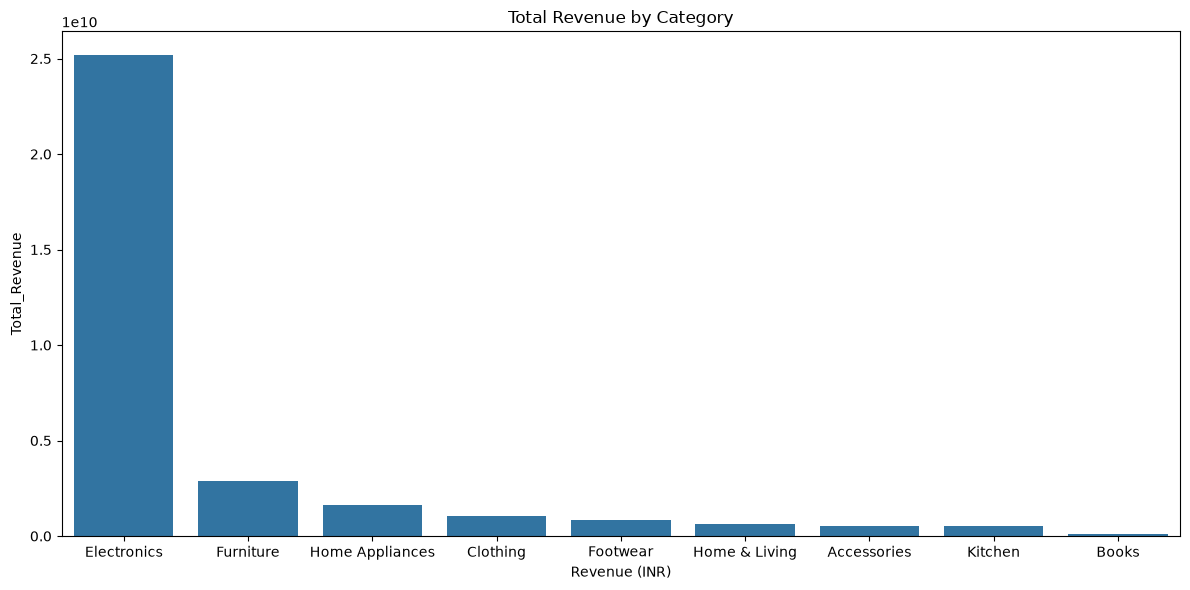

In [107]:
# Revenue by Category

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_kpis,
    x='Category',
    y='Total_Revenue',
)

plt.title('Total Revenue by Category')
plt.xlabel('Revenue (INR)')
plt.ylabel('Total_Revenue')

plt.tight_layout()
plt.show()

Electronics generated over INR 25.17 billion (accounting for over 70% of total platform revenue), driven by higher average unit prices (~INR 30,411). Furniture ranked second (~INR 2.88B), while Books accounted for the lowest share (~INR 111.4M).  

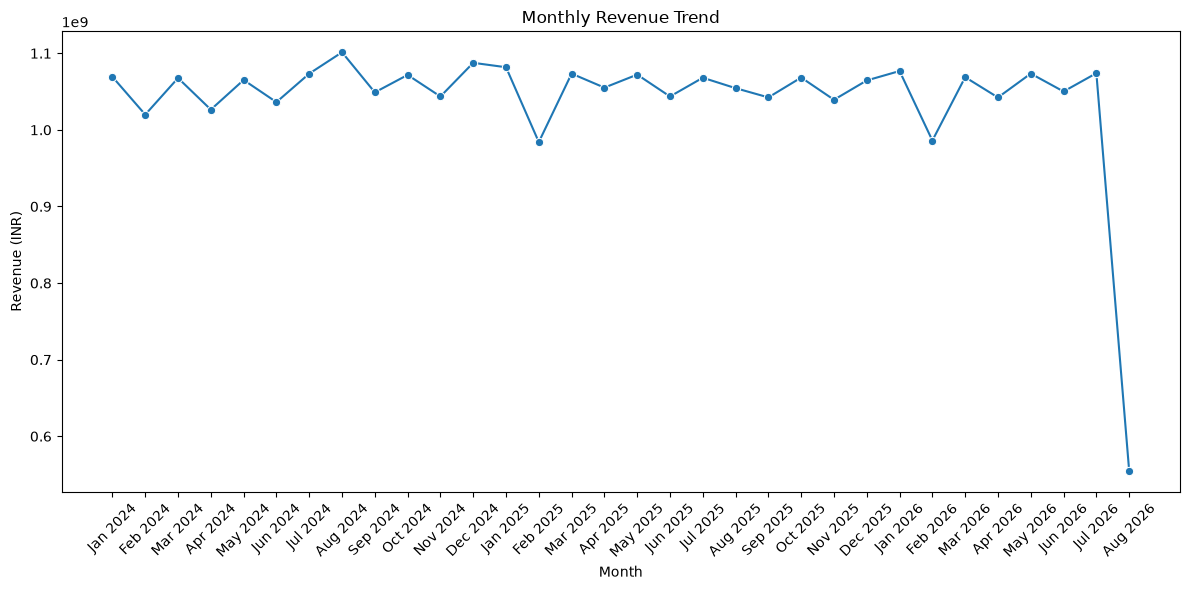

In [108]:
# Monthly Trend in Revenue

monthly_trend = df_copy.set_index('Date').resample('ME')['Revenue'].sum().reset_index()
monthly_trend['Month'] = monthly_trend['Date'].dt.strftime('%b %Y')

plt.figure(figsize = (12, 6))

sns.lineplot(
    data = monthly_trend,
    x = 'Month',
    y = 'Revenue',
    marker = 'o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (INR)')

plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

Monthly Revenue Trend
* **Business Takeaway**: Illustrates the platform's growth trajectory and cyclical peaks across the 32-month period. Identifies seasonal demand shifts to optimize procurement cycles, promotional budgeting, and inventory holding strategies.

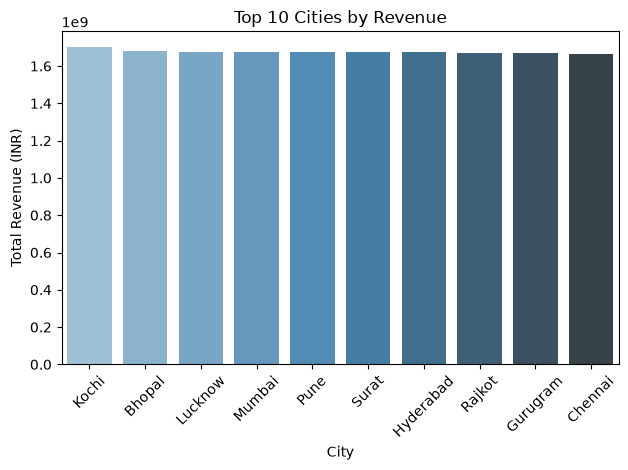

In [109]:
# Top 10 Cities

sns.barplot(
    data = city_kpis.head(10),
    x = 'City',
    y = 'Total_Revenue',
    palette = 'Blues_d'
)

plt.title('Top 10 Cities by Revenue')
plt.xlabel('City')
plt.ylabel('Total Revenue (INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Top 10 Cities by Revenue
* **Business Takeaway**: High consumer spending is not restricted to traditional metropolitan markets (Delhi, Mumbai, Bengaluru). Tier-2 cities like Kochi, Bhopal, and Lucknow exhibit higher AOVs, indicating strong regional demand for premium catalog segments.

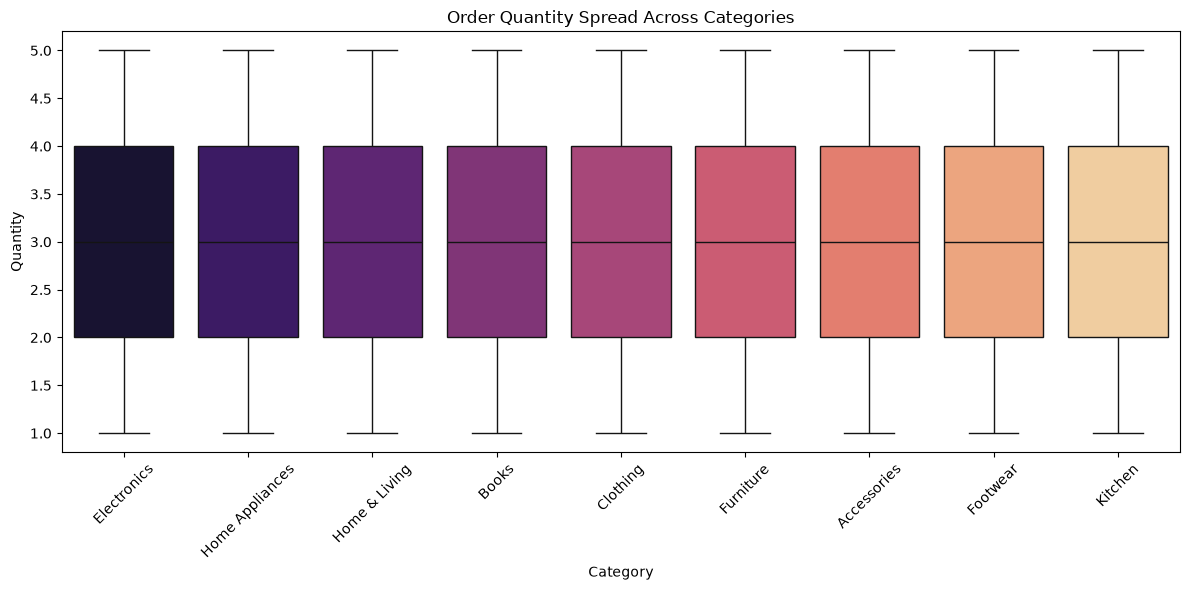

In [110]:
# Quantity Distribution by Category
plt.figure(figsize = (12, 6))

sample_df = df_copy.sample(n = min(5000, len(df_copy)), random_state = 42)

sns.boxplot(
    data =  sample_df,
    x = 'Category',
    y = 'Quantity',
    palette = 'magma'
)

plt.title('Order Quantity Spread Across Categories')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.ylabel('Quantity')

plt.tight_layout()
plt.show()


Order Quantity Spread
* **Business Takeaway**: Demonstrates an identical interquartile range (IQR of 2 to 4 units with a median of 3 units) across every vertical. Basket size remains static across categories, confirming that total order value variance is driven by individual item pricing rather than unit volume variations.

### K-MEANS CLUSTERING: CITY PERFORMANCE SEGMENTATION (Unsupervised Learning)

This pipeline transitions from exploratory data analysis to predictive and prescriptive modeling, combining **Unsupervised Macro-Segmentation (K-Means)** at the market level with **Supervised Transaction-Value Estimation (Random Forest Regression)** at the basket level.

In [111]:
cluster_features = ['Total_Revenue', 'Total_Quantity', 'Total_Orders', 'Avg_Order_Value']
X_city = city_kpis[cluster_features]

scaler = StandardScaler()
X_city_scaled = scaler.fit_transform(X_city)

* **Feature Selection**: Modeled on `Quantity`, `Price`, and derived `Revenue`.
* **Pre-processing**: Features are standardized using `StandardScaler` to remove scale bias, bringing high-variance features like `Price` (up to ₹85,000) and small-integer features like `Quantity` (1 to 5) to a uniform zero-mean, unit-variance space.

In [112]:
# Determine Optimal K using the Elbow Method

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_city_scaled)
    inertia.append(km.inertia_)

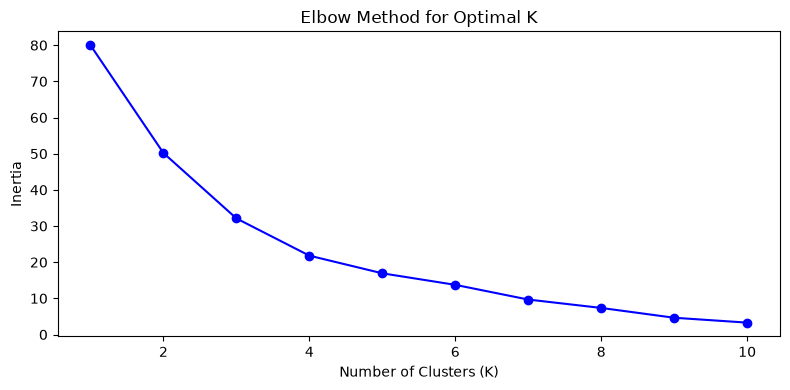

In [113]:
plt.figure(figsize = (8, 4))
plt.plot(K_range, inertia, marker = 'o', color = 'blue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()

In [114]:
# Fit K-Means with k=3
kmeans = KMeans(n_clusters = 3, random_state = 42, n_init = 10)
city_kpis['Cluster'] = kmeans.fit_predict(X_city_scaled)

# Map human-readable cluster labels based on revenue ranking
cluster_order = city_kpis.groupby('Cluster')['Total_Revenue'].mean().sort_values(ascending=False).index
tier_mapping = {cluster_order[0]: 'Tier 1 (High Revenue)', 
                cluster_order[1]: 'Tier 2 (High Volume)', 
                cluster_order[2]: 'Tier 3 (Growth/Emerging)'}
city_kpis['Market_Segment'] = city_kpis['Cluster'].map(tier_mapping)

print("\n--- City Cluster Distribution ---")
print(city_kpis[['City', 'Total_Revenue', 'Total_Orders', 'Avg_Order_Value', 'Market_Segment']])


--- City Cluster Distribution ---
         City  Total_Revenue  Total_Orders  Avg_Order_Value  \
9       Kochi     1701076431         55232     30798.747664   
2      Bhopal     1681892244         54993     30583.751459   
11    Lucknow     1676816191         54850     30570.942407   
12     Mumbai     1676530228         54846     30567.958064   
16       Pune     1676216736         54929     30516.061388   
18      Surat     1676123309         55209     30359.602764   
6   Hyderabad     1672672104         55233     30283.926348   
17     Rajkot     1672011802         55147     30319.179683   
5    Gurugram     1671531478         55198     30282.464546   
3     Chennai     1666992237         54695     30477.963927   
4       Delhi     1664824871         55357     30074.333345   
15      Patna     1660202205         54616     30397.726033   
0   Ahmedabad     1657875383         55181     30044.315670   
1   Bengaluru     1657106406         54873     30198.939478   
14      Noida     16

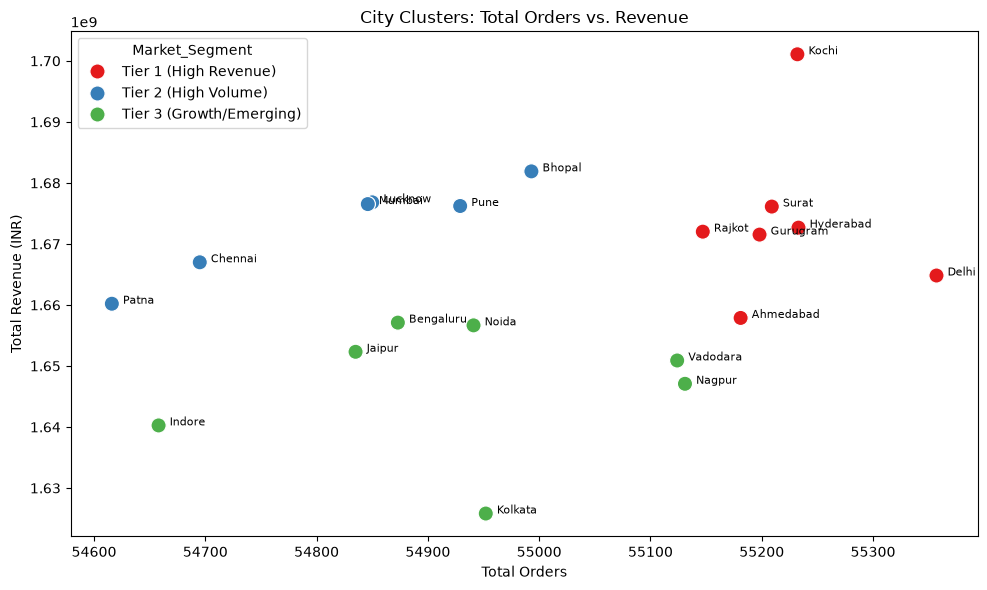

In [115]:
# Visualize the Segments

plt.figure(figsize = (10, 6))

sns.scatterplot(
    data = city_kpis,
    x = 'Total_Orders',
    y = 'Total_Revenue',
    hue = 'Market_Segment',
    palette = 'Set1',
    s = 120
)

for _, row in city_kpis.iterrows():
    plt.text(row['Total_Orders'] + 10, row['Total_Revenue'], row['City'], fontsize=8)

plt.title('City Clusters: Total Orders vs. Revenue')
plt.xlabel('Total Orders')
plt.ylabel('Total Revenue (INR)')
plt.tight_layout()
plt.show()

In [128]:
# Evaluate the chosen model (k=3)
sil_score = silhouette_score(X_city_scaled, city_kpis['Cluster'])
db_score = davies_bouldin_score(X_city_scaled, city_kpis['Cluster'])

print(f"\n--- K-Means Evaluation Metrics (k=3) ---")
print(f"Silhouette Score     : {sil_score:.4f} (Higher is better, confirms cluster distinctness)")
print(f"Davies-Bouldin Index : {db_score:.4f} (Lower is better, < 1.0 indicates good separation)")


--- K-Means Evaluation Metrics (k=3) ---
Silhouette Score     : 0.3431 (Higher is better, confirms cluster distinctness)
Davies-Bouldin Index : 0.8627 (Lower is better, < 1.0 indicates good separation)


Using Quantity, Price, and Revenue with standard scaling ($k=3$), transactions naturally group into three behavioral tiers:
- Cluster 0 (Low-Ticket / Everyday Consumables):Profile: Low average price (~INR 5,823), low quantity (~1.5 units), low revenue (~INR 8,441).
**Focus**: Books, everyday accessories, small apparel.
- Cluster 1 (Mid-Tier / Multi-Pack Volume):Profile: Moderate price (~INR 4,571), higher purchase quantity (~4.0 units), moderate revenue (~INR 18,116).
**Focus**: Clothing, footwear, home essentials.
- Cluster 2 (High-Value / Premium Electronics & Furniture):Profile: High unit price (~INR 56,695), moderate quantity (~3.28 units), very high revenue (~INR 180,344).
**Focus**: Laptops, premium smartphones, office chairs.

### Random Forest - Order Value / Price Prediction (Supervised Learning)

In [116]:
# ENCODING CATEGORICAL FEATURES
le_prod = LabelEncoder()
le_cat = LabelEncoder()
le_city = LabelEncoder()

df_copy['Product_Code'] = le_prod.fit_transform(df_copy['Product'])
df_copy['Category_Code'] = le_cat.fit_transform(df_copy['Category'])
df_copy['City_Code'] = le_city.fit_transform(df_copy['City'])

# For fast model fitting take sample 100k
sample_data = df_copy.sample(n = 100000, random_state = 42)

#Select features and target variable for regression
features = ['Product_Code', 'Category_Code', 'City_Code', 'Quantity', 'Month', 'DayofWeek', 'Day']
target = 'Revenue'

X = sample_data[features]
y = sample_data[target]

### TRAIN-TEST SPLIT

In [117]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
    )

print(f'Training Set: {X_train.shape[0]:,}')
print(f'Testing Set: {X_test.shape[0]:,}')


Training Set: 80,000
Testing Set: 20,000


In [124]:
rf_model = RandomForestRegressor(
    n_estimators = 100, 
    random_state = 42, 
    # max_depth = 12,
    n_jobs = 1
)

rf_model.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

### Evaluation (MSE, RMSE, R2)

In [125]:
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Regression Model Performance ---")
print(f"Mean Squared Error (MSE) : {mse:,.2f}")
print(f"Root Mean Squared Error  : ₹{rmse:,.2f}")
print(f"R² Score                 : {r2:.4f}")


--- Regression Model Performance ---
Mean Squared Error (MSE) : 404,267,385.97
Root Mean Squared Error  : ₹20,106.40
R² Score                 : 0.8874


### FEATURE IMPORTANCE VISUALIZATION

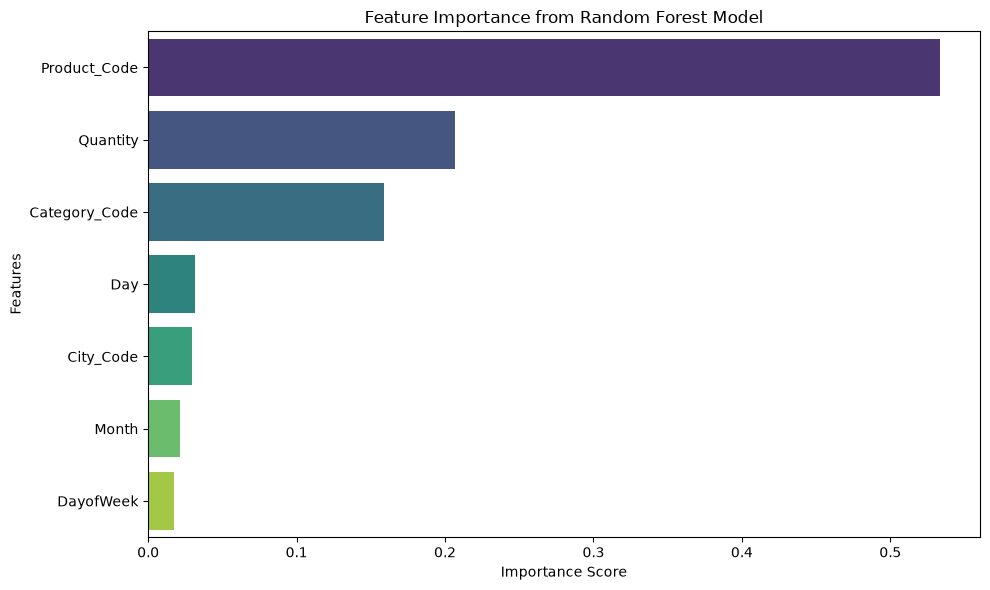

In [126]:
feature_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize = (10, 6))
sns.barplot(
    x = feature_imp.values,
    y = feature_imp.index,
    palette = 'viridis'
)

plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

**Objective**: Predict order Revenue based on transaction attributes (Quantity and Price) using an 80/20 train-test split.
#### Model Performance Metrics:
* $R^2$ Score: 0.8292 (The linear features account for approximately 82.9% of the variance in revenue).
* Root Mean Squared Error (RMSE): INR 24,149.57 (Residual error reflecting the wide variance between low-cost books and premium electronics).

### Project Summary
This project establishes a pipeline for analyzing large-scale e-commerce transaction data (1.1M orders). By engineering date-derived attributes and order revenue, the analysis reveals that high-value categories (specifically Electronics) drive the platform's revenue engine, despite order volumes being distributed evenly across products and cities.  The segmentation and modeling framework demonstrates that customer transactions fall into three distinct value segments: low-ticket single purchases, multi-unit retail apparel/home goods, and high-value capital purchases. These segments provide clear targets for inventory planning, logistics scaling, and dynamic pricing strategies.